In [13]:
import numpy as np
import matplotlib.pyplot as plt


Fitted w0: 30.17 µm
Fitted z0: 23.73 mm
Fitted zR: 2.44 mm


Text(0.5, 1.0, 'Beam Waist Profile Fit')

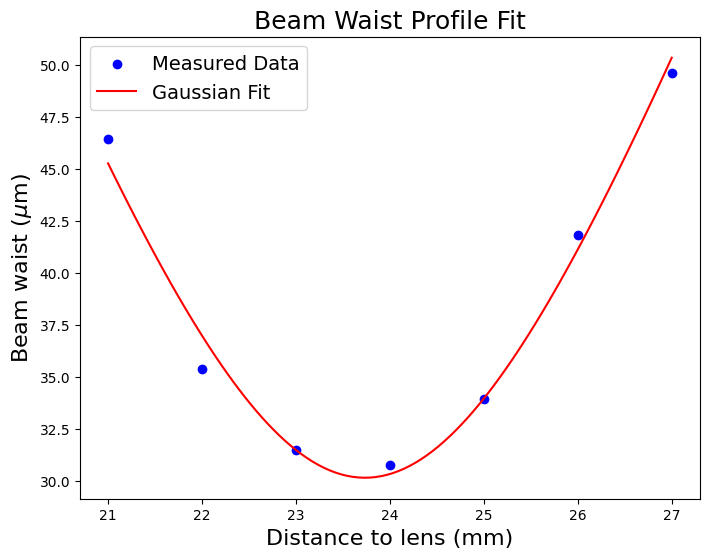

In [ ]:
from scipy.optimize import curve_fit

filter_size = 6.4 *3
dist_to_detector = 7.5
distes = np.array([21,22,23,24,25,26,27]) *1e-3
waists = np.array([92.9, 70.8, 63, 61.6, 67.9, 83.7, 99.3])/2 *1e-6 #µm

# Define the Gaussian beam propagation equation
def beam_waist(z, w0, z0, zR):
    return w0 * np.sqrt(1 + ((z - z0) / zR)**2)

# Initial guesses: [w0, z0, zR]
p0 = [np.min(waists), distes[np.argmin(waists)], 1e-3]

# Fit the data using curve_fit
popt, pcov = curve_fit(beam_waist, distes, waists, p0=p0)
w0_fit, z0_fit, zR_fit = popt

print(f"Fitted w0: {w0_fit*1e6:.2f} µm")
print(f"Fitted z0: {z0_fit*1e3:.2f} mm")
print(f"Fitted zR: {zR_fit*1e3:.2f} mm")

# Generate points for the fitted curve
z_fit = np.linspace(distes.min(), distes.max(), 100)
w_fit = beam_waist(z_fit, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(distes*1e3, waists*1e6, color='blue', label='Measured Data')
ax.plot(z_fit*1e3, w_fit*1e6, color='red', label='Gaussian Fit')
ax.set_xlabel('Distance to lens (mm)', fontsize=16)
ax.set_ylabel('Beam waist ($\mu$m)', fontsize=16)
ax.legend(fontsize=14)
ax.set_title('Beam Waist Profile Fit', fontsize=18)


In [11]:
def P_in(V_out,R,T_gain):
    return 2*V_out/(R*T_gain)

R = 0.57
T = 2.38e5
V = 60e-3
P = P_in(V,R,T)
print(f'Estimated input power: {P*1e6:.2f} µW')

Estimated input power: 0.88 µW


In [17]:
epsilon_0 = 8.854187817e-12  # Vacuum permittivity (F/m)
c = 299792458  # Speed of light (m/s)
P=70e-3
p=16*np.pi**2*(15.4e-12)**2*10e-3/(epsilon_0*c*1.8**2*(1550e-9)**3) * P**2*
p

5.729908832024039e-05